# Итоговое домашнее задание
## Современные методы анализа данных
`PS_2026.06.25_09.28.45.csv` - файл содержит информацию о экзопланетах и коричневых карликах. 

Данные взяты с сайта NASA Exoplanet Archive https://exoplanetarchive.ipac.caltech.edu/index.html.

Обозначения колонок:

`pl_name` - название планеты

`sy_snum` - кол-во звёзд в звёздной системе планеты

`discoverymethod` - метод открытия

`disc_year` - год открытия

`pl_radj` - радиус планеты в радиусах Юпитера

`pl_bmassj`- масса в массах Юпитера или масса умноженная на $sin(i)$, где $i$-угол наклона орбиты планеты

`pl_controv_flag` - значения, которые показывают статус планет (кандидат или подтвержденная планета). 

`soltype` - флаг указывающий на то, подвергается ли сомнению статус планеты

Данные подобраны так, чтобы все планеты были подтвержденны. Также сделано так, чтобы у каждой планеты были определены масса и размер. Так как методы изучения не могут дать данные о размерах и массах экзопланет одновременно это означает, что каждая планета изучалась несколькими методами.

Цели: 

-проанализировать как менялось количество открытых планет с годами

-проанализировать отношение планет в двойных и одиночных системах

-проанализировать по методу открытия

-найти зависимость размера планеты от ее массы




-присоединить датафрейм со звездами. Покрасить планеты по классу звезд, к которым они принадлежат

In [14]:
import numpy as np #Подключим нужные библиотеки и посмотрим как выглядит датасет
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('PS_2026.06.25_09.39.08.csv', skiprows=20)
#В csv описано, что означает каждый столбик, поэтому пропускаем эти строчки
data.sample(5)

,pl_name,sy_snum,discoverymethod,disc_year,soltype,pl_controv_flag,pl_radj,pl_bmassj
2653,HD 15337 b,1,Transit,2019.0,Published Confirmed,0,0.146311,0.023629
1418,Kepler-41 b,1,Transit,2011.0,Published Confirmed,0,0.890000,0.550000
775,WASP-121 b,1,Transit,2016.0,Published Confirmed,0,1.865000,1.183000
3336,LTT 1445 A c,3,Transit,2022.0,Published Confirmed,0,0.142743,0.003146
2238,Kepler-177 c,1,Transit,2013.0,Published Confirmed,0,0.778838,0.046251


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3381 entries, 0 to 3380
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          3381 non-null   object 
 1   sy_snum          3381 non-null   int64  
 2   discoverymethod  3381 non-null   object 
 3   disc_year        3380 non-null   float64
 4   soltype          3381 non-null   object 
 5   pl_controv_flag  3381 non-null   int64  
 6   pl_radj          3381 non-null   float64
 7   pl_bmassj        3381 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 211.4+ KB


Видим,что в `disc_year` есть пропущеное значение

In [16]:
missing_rows = data[data.isnull().any(axis=1)]# ищем пропущенные значения
missing_rows

,pl_name,sy_snum,discoverymethod,disc_year,soltype,pl_controv_flag,pl_radj,pl_bmassj
2918,TOI-5789 c,1,Transit,NaN,Published Confirmed,0,0.255153,0.015732


По названию планеты на сайте ищем что с ней не так
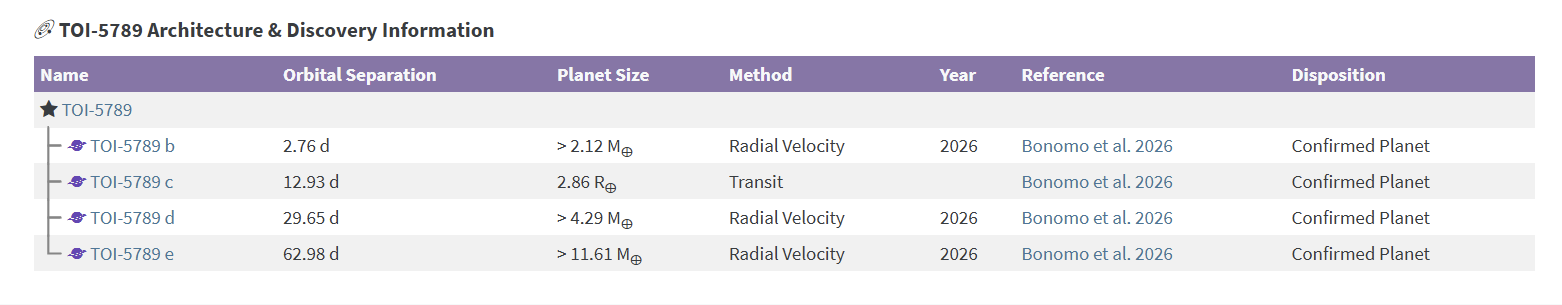
Препринт опубликован за 2026 год. Давайте такой год и поставим для этой планеты

In [17]:
data_copy=data.copy()
data_copy.loc[data['pl_name'] == 'TOI-5789 c', 'disc_year'] = 2026.0
data_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3381 entries, 0 to 3380
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          3381 non-null   object 
 1   sy_snum          3381 non-null   int64  
 2   discoverymethod  3381 non-null   object 
 3   disc_year        3381 non-null   float64
 4   soltype          3381 non-null   object 
 5   pl_controv_flag  3381 non-null   int64  
 6   pl_radj          3381 non-null   float64
 7   pl_bmassj        3381 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 211.4+ KB


In [63]:
pl_name_counts = data_copy['pl_name'].value_counts() # проблема: некоторые планеты упоминаются в разных статьях
pl_name_counts.head(5)

TrES-2 b       16
HD 209458 b    11
WASP-4 b       11
Kepler-10 b    10
WASP-18 b      10
Name: pl_name, dtype: int64

In [62]:
data_copy[data_copy['pl_name'] == 'K2-3 d']

,pl_name,sy_snum,discoverymethod,disc_year,soltype,pl_controv_flag,pl_radj,pl_bmassj
2373,K2-3 d,1,Transit,2015.0,Published Confirmed,0,0.136497,0.034924
2658,K2-3 d,1,Transit,2015.0,Published Confirmed,0,0.135605,0.023598
3170,K2-3 d,1,Transit,2015.0,Published Confirmed,0,0.135606,0.008810
3221,K2-3 d,1,Transit,2015.0,Published Confirmed,0,0.130074,0.006922
3272,K2-3 d,1,Transit,2015.0,Published Confirmed,0,0.147203,0.005663
3291,K2-3 d,1,Transit,2015.0,Published Confirmed,0,0.144527,0.005034


Для каждой планеты должны быть уникальные значения массы и радиуса. В данных же мы видим, что некоторые планеты повторяются с разными значениями этих параметров. Это связано с тем, что по каждой планете могло быть несколько исследований с разными результатами.

Для простоты расчетов и уменьшения влияния выбросов значений на данные (в примере выше минимальное и максимальное значения массы отличаются почти в 7 раз) будем просто брать медианные значения радиуса и массы)

In [65]:
cleaned_df = (
    data_copy.groupby('pl_name')
    .agg({
        'sy_snum': 'first',
        'discoverymethod': 'first',
        'disc_year': 'first',  
# Столбцы выше не должны меняться. Столбцы с флагом и статусом убрал, т.к. они больше не нужны
        'pl_radj': 'median',  
        'pl_bmassj': 'median'
    })
    .reset_index()
)
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1680 entries, 0 to 1679
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          1680 non-null   object 
 1   sy_snum          1680 non-null   int64  
 2   discoverymethod  1680 non-null   object 
 3   disc_year        1680 non-null   float64
 4   pl_radj          1680 non-null   float64
 5   pl_bmassj        1680 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 78.9+ KB


In [25]:
cleaned_df['sy_snum'].value_counts() #сколько звёзд в стстеме

1    1422
2     222
3      35
4       1
Name: sy_snum, dtype: int64

Считается, что количество одинарных и двойных звёзд примерно равно (https://ru.wikipedia.org/wiki?curid=8610527).

Но в наших данных получилось, что число планет у одиночных систем почти в 7 раз больше. Это может быть связано как и с гравитационной нестабильностью таких систем, так и с особенностями отбора данных. Методы поиска экзопланет (например, транзитный или метод лучевых скоростей) хуже работают в двойных системах из-за наложения световых сигналов и сложных орбит.

In [66]:
cleaned_df['discoverymethod'].value_counts() #каким образом открыли

Transit                          1603
Imaging                            36
Radial Velocity                    31
Transit Timing Variations           9
Orbital Brightness Modulation       1
Name: discoverymethod, dtype: int64

Подавляющее число планет в датафрейме открыто транзитным методом. Это является следствием специфической выборки. Если бы мы не выбирали планеты где известна и масса и радиус отношение планет открытых транзитным методом к методу радиальных скоростей было бы 3:1

In [30]:
data_copy.describe() #средние значения планет. большие отклонения - разные типы+

,sy_snum,disc_year,pl_controv_flag,pl_radj,pl_bmassj
count,3381.000000,3381.000000,3381.0,3381.000000,3381.000000
mean,1.215025,2015.492458,0.0,0.764568,1.203247
std,0.476885,5.585565,0.0,0.556860,3.132980
min,1.000000,1999.000000,0.0,0.026435,0.000205
25%,1.000000,2011.000000,0.0,0.221120,0.027530
50%,1.000000,2015.000000,0.0,0.831000,0.297000
75%,1.000000,2020.000000,0.0,1.210000,1.090000
max,4.000000,2026.000000,0.0,7.780000,80.000000


Видим, что средний радиус и средняя масса планет близки к массе Юпитера. Максимальное значение массы 80, что соответствует классу Коричневых карликов - промежуточному объекту между планетами и звездами. При анализе отношения массы/радиуса нужно будет учитывать это.

In [33]:
data_copy.groupby('sy_snum')['pl_bmassj'].describe()

,count,mean,std,min,25%,50%,75%,max
sy_snum,,,,,,,,
1,2752.0,1.159860,3.267719,0.000205,0.025171,0.2005,1.0000,80.000
2,532.0,1.263502,2.358487,0.000913,0.050342,0.6705,1.2005,28.000
3,96.0,2.120111,2.827559,0.000315,0.096671,1.3320,1.9125,13.800
4,1.0,0.531000,NaN,0.531000,0.531000,0.5310,0.5310,0.531


В датасете только одна система с 4 звездами, поэтому делать на основании её какие-то выводы (кроме того, что такие системы существуют) мы не будем. Видим, что планеты в двойных и тройных системах в средним имеют больший вес. Это объяснеется методом отбора данных. Чем выше отношение массы планеты к массе звезды (или звезд) вокруг которых она вращается тем проще ее обнаружить. Это обясняет рост значений для множественных систем.

Рассмотрим какое кол-во планет находили в разные годы.

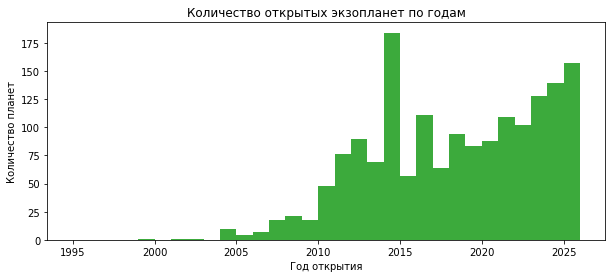

In [68]:
years = cleaned_df['disc_year'].dropna().round().astype(int)
ax = years.plot.hist(bins=range(1995, 2027), figsize=(10, 4), color='#3caa3c')
# Окрашиваем столбцы в цвет влюбленной жабы - #3caa3c, чтобы было веселее.
ax.set_title('Количество открытых экзопланет по годам')
ax.set_ylabel('Количество планет')
ax.set_xlabel('Год открытия');

Начало роста числа найденых планет 2010 год - год запуска телескопа "Кеплер", который был запущен для поиска экзопланет транзитным методом.

Резкий скачек в 2014 - комманда "Кеплера" модифицировала методику проверки данных и обнаружила разом порядка 2000 планет.

Скачек в 2018 - запуск телескопа TESS.

Text(0, 0.5, 'Радиус (в радиусах Юпитера)')

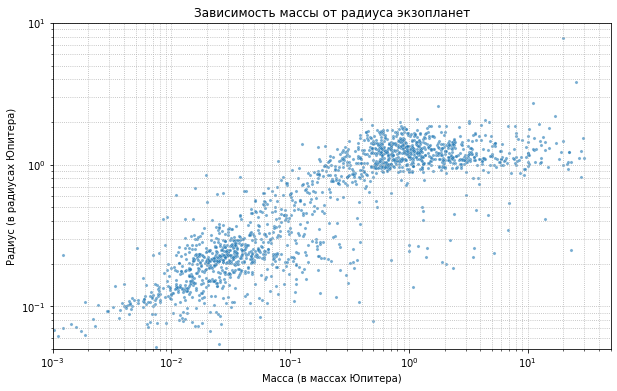

In [73]:
import seaborn as sns

clean_plot = cleaned_df.copy()
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clean_plot,
    x='pl_bmassj', y='pl_radj',
    alpha=0.6, s=10
)


plt.xscale('log'); plt.yscale('log')
plt.xlim(1e-3, 50)
plt.ylim(5e-2, 10)
plt.grid(True, which='both', ls=':')
plt.title('Зависимость массы от радиуса экзопланет')
plt.xlabel('Масса (в массах Юпитера)')
plt.ylabel('Радиус (в радиусах Юпитера)')

Видим, что для объектов, чья масса меньше массы Юпитера примерно в половину зависимость $M \sim R^\alpha$ (почти линейная на графике log). Это логично: масса пропорциональна объёму тела, а объем тела кубу его размера. В реальности $\alpha<3$ по нескольким причинам:
* Многие из обнаруженных планет - газовые гиганты, а значит их плотность будет ниже, а масса всё равно большой из-за тяжелого плотного ядра
* Вещество в недрах планет может сжимается силами гравитации и формула $M \sim R^\alpha$ становится не применима. Именно из-за этого эффекта график выходит на плато для объектов, чья масса больше массы Юпитера. Размеры коричневых карликов практически не меняются при росте массы
* Определение масс планет с помощью Допплер-эффекта дает оценку с точностью до $sin(i)$, что связано с недостатками рассчетов самого метода
* Транзитный метод может давать большие погрешности для маленьких планет. Появления звёздных пятен и вспышек будут давать дополнительные шумы.